# Charter.4 醫學骨密度分析
本章節將透過骨密度的角度分析
先備知識:醫學相關名詞理解
MicroDicom安裝
一般的掃描為3D array scan
在此專案中會透過MicroDicom的部分了解到模型如何處理3D Tensor
安裝好後的畫面長這樣:
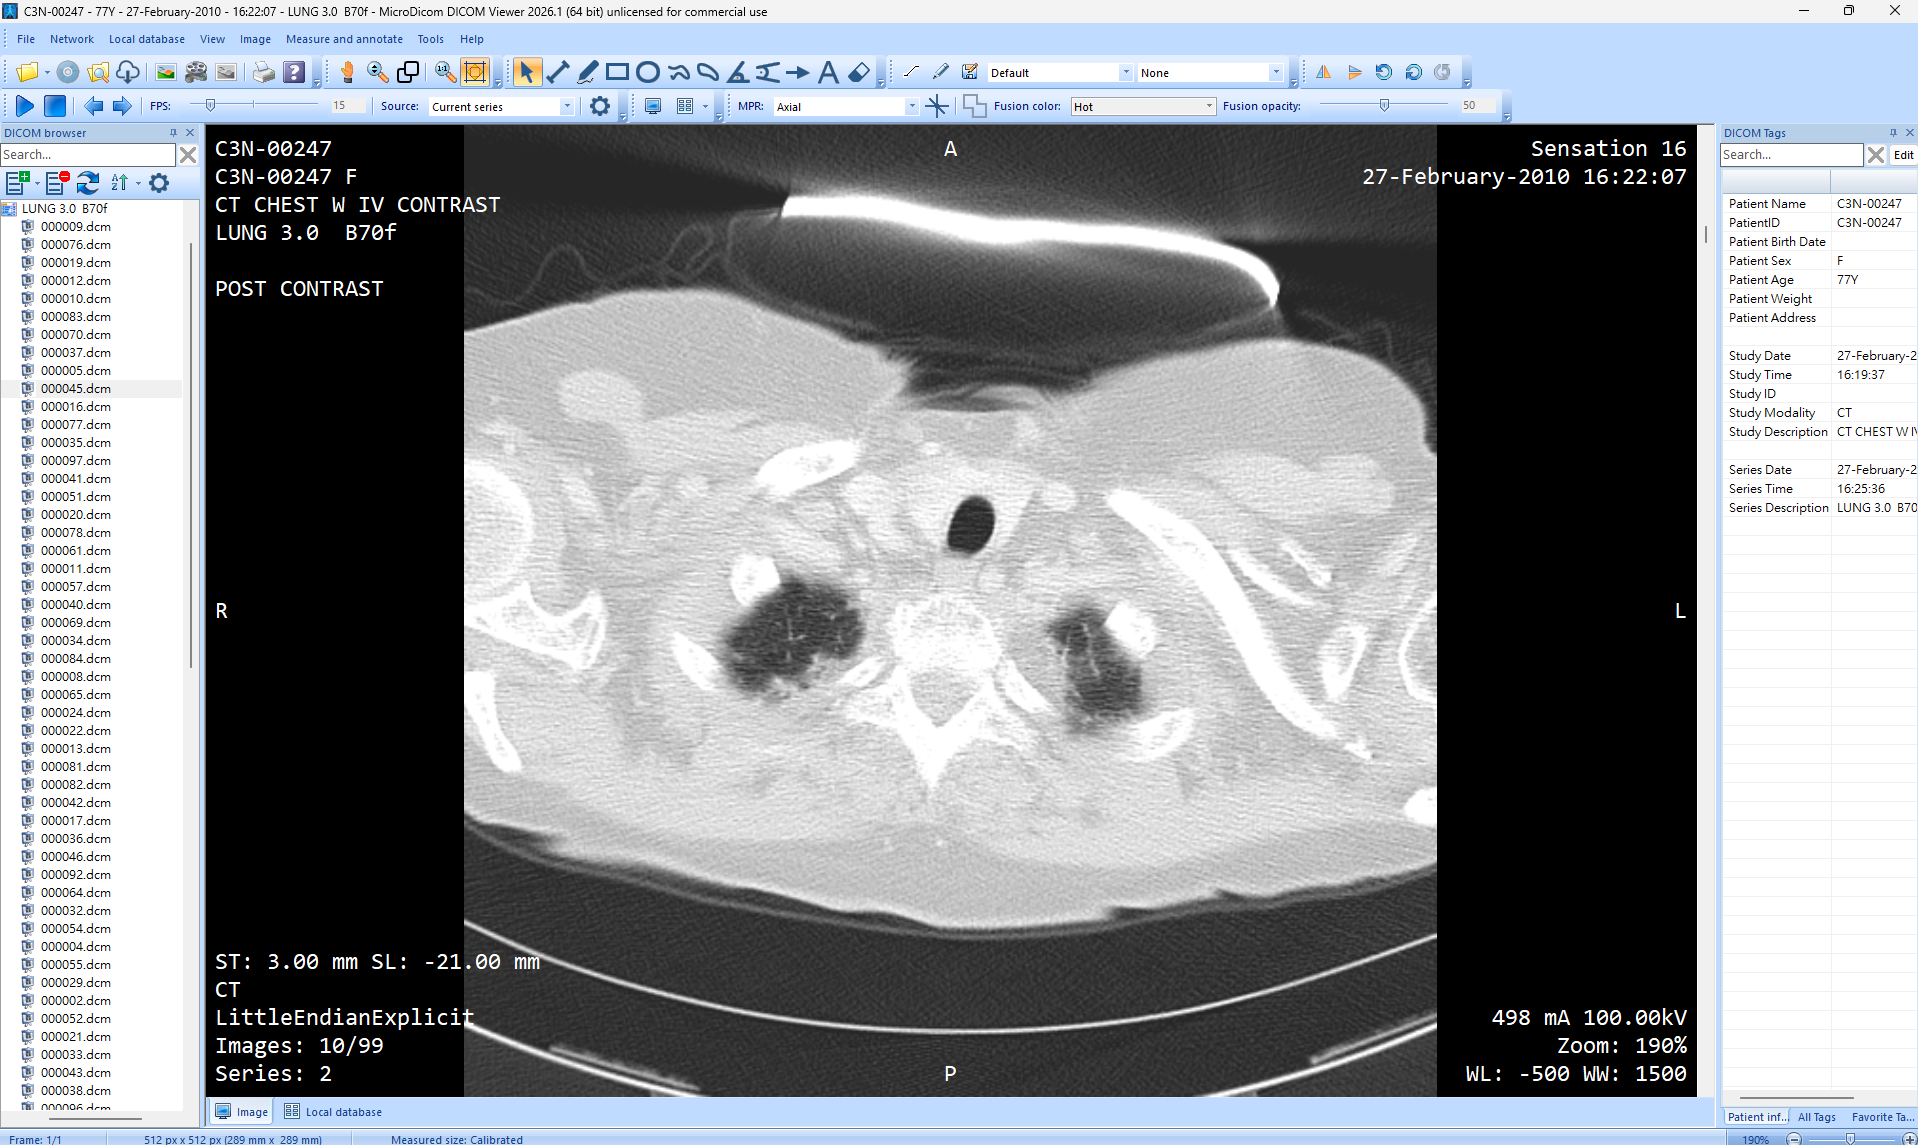

上圖的範例為肺的掃描圖
# 4-2-1 載入特定格式的資料

In [62]:
import imageio

path="./2-LUNG 3.0  B70f-04083"
vol_arr=imageio.volread(path,"dicom")
vol_arr.shape


Reading DICOM (examining files): 1/99 files (1.0%99/99 files (100.0%)
  Found 1 correct series.
Reading DICOM (loading data): 99/99  (100.0%)


(99, 512, 512)

上面已經導入了剛剛肺部的掃描圖,現在我們把Tensor進入到torch

In [63]:
import torch
vol = torch.from_numpy(vol_arr).float()
vol = torch.unsqueeze(vol,1)
vol = torch.unsqueeze(vol,2)
vol.shape

torch.Size([99, 1, 1, 512, 512])

# 4-3 表格資料
- 連續數值
    - 有時間關係
    - 有規律關西
- 有序數值
    - 有規律關係
    - 只分大小
- 類別數值
    - 無法排序
    - 無規律
# 4-3-1 使用真實世界中的資料集
在此專案中我們以葡萄酒的品質資料集作為範例
並使用這個資料集用來預測品質分數,因為酒會隨時間揮發二氧化硫的濃度進而變更風味,所以可以透過這個方式來判定酒的品質

In [64]:
import csv
import numpy as np
path="./winequality-white.csv"
wine_numpy = np.loadtxt(path, delimiter=";", skiprows=1,dtype=np.float32)

wine_numpy

array([[ 7.  ,  0.27,  0.36, ...,  0.45,  8.8 ,  6.  ],
       [ 6.3 ,  0.3 ,  0.34, ...,  0.49,  9.5 ,  6.  ],
       [ 8.1 ,  0.28,  0.4 , ...,  0.44, 10.1 ,  6.  ],
       ...,
       [ 6.5 ,  0.24,  0.19, ...,  0.46,  9.4 ,  6.  ],
       [ 5.5 ,  0.29,  0.3 , ...,  0.38, 12.8 ,  7.  ],
       [ 6.  ,  0.21,  0.38, ...,  0.32, 11.8 ,  6.  ]],
      shape=(4898, 12), dtype=float32)

表示欄位名稱

In [65]:
col_list = next(csv.reader(open(path), delimiter=";"))
wine_numpy.shape,col_list

((4898, 12),
 ['fixed acidity',
  'volatile acidity',
  'citric acid',
  'residual sugar',
  'chlorides',
  'free sulfur dioxide',
  'total sulfur dioxide',
  'density',
  'pH',
  'sulphates',
  'alcohol',
  'quality'])

表示資料大小

In [66]:
wineq = torch.from_numpy(wine_numpy)
wineq.shape,wineq.dtype

(torch.Size([4898, 12]), torch.float32)

表示品質分數

In [67]:
target = wineq[:,-1]
target,target.shape

(tensor([6., 6., 6.,  ..., 6., 7., 6.]), torch.Size([4898]))

# 4-3-4 one-hot 編碼
可以用  **torch.scatter_()** function進行編碼

In [68]:
target_onehot = torch.zeros(target.shape[0],10)
a = target_onehot.scatter_(1,target.long().unsqueeze(1),1.0)
a


tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])